<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MC con Políticas epsilon-soft (off-policy)**

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "CliffWalking", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando obstáculos.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "CliffWalking"**:
Se carga el entorno "CliffWalking".

- **Funciones para Mostrar los Resultados**: Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gym
%pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]

In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

In [3]:
#@title Importamos el entorno cliff walking
# https://gymnasium.farama.org/environments/toy_text/cliff_walking/
env_discrete = gym.make("CliffWalking-v1", render_mode = "ansi")

# Definimos las acciones
UP, RIGHT, DOWN, LEFT = 0,1,2,3

## **2. Diseño del Agente**

El diseño del agente consta de dos partes: el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
  - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida. Esta política se utiliza como behavior policy en el escenario off-policy.
  - **Política epsilon-greedy**: Basada en la política epsilon-soft. Permite al agente explorar con cierta probabilidad y explotar la mejor acción conocida con mayor probabilidad.
  - **Política greedy**: Es la target policy que el agente aprende y sigue para maximizar la recompensa esperada una vez completado el entrenamiento.

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de Monte Carlo off-policy utilizando importancia de muestreo.
  - Se usa una $\epsilon$ constante para la política behavior, asegurando exploración suficiente y estabilidad en los pesos de importancia.
  - La actualización de Q se realiza de manera incremental considerando todos los retornos del episodio y ponderando por los pesos de importancia.

#### **Código de las políticas y algoritmo MC (off-policy)**
----------------

In [27]:
# @title Políticas del agente

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

def pi_star_from_Q_offpolicy(env, Q):
    """
    Genera la política greedy a partir de Q (off-policy) de manera rápida.

    Devuelve:
    - pi_star: matriz [nS, nA] con la acción elegida marcada
    - actions: string con acciones óptimas por estado
    - grid_str: representación del entorno en ASCII (solo inicial/final)
    """
    nS, nA = Q.shape

    # Acción óptima por estado
    best_actions = np.argmax(Q, axis=1)

    # Matriz pi_star como antes
    pi_star = np.zeros((nS, nA), dtype=int)
    for s in range(nS):
        pi_star[s, best_actions[s]] = best_actions[s]

    # String de acciones
    actions_str = ", ".join(str(a) for a in best_actions)

    # Grid ASCII: solo render del entorno inicial/final
    grid_str = env.render()

    return pi_star, actions_str, grid_str

In [5]:
def mc_off_policy_all_visit(env, num_episodes=5000, gamma=0.95, epsilon=0.3, max_steps=50):
    """
    Monte Carlo Off-Policy Control usando Importance Sampling (all-visit), optimizado.
    Target policy: greedy
    Behavior policy: epsilon-soft con ε constante
    max_steps: tamaño máximo del episodio (para preasignar arrays de NumPy)
    """
    nS = env.observation_space.n
    nA = env.action_space.n

    # Q y acumulador de pesos de importancia
    Q = np.zeros((nS, nA))
    C = np.zeros((nS, nA))

    # Política objetivo (greedy)
    pi_star = np.zeros(nS, dtype=int)

    # Recompensas por episodio
    episode_rewards = []

    # Pre-calculo de inv_prob para W
    inv_prob = nA / epsilon

    # Arrays para almacenar episodio de manera eficiente
    states = np.zeros(max_steps, dtype=int)
    actions = np.zeros(max_steps, dtype=int)
    rewards = np.zeros(max_steps, dtype=float)

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=100)
        done = False
        step = 0
        total_reward = 0

        # Generar episodio
        while not done and step < max_steps:
            # Behavior policy ε-soft
            action_probs = random_epsilon_greedy_policy(Q, epsilon, state, nA)
            action = np.random.choice(nA, p=action_probs)
            next_state, reward, terminated, truncated, info = env.step(action)

            # Guardar paso en arrays
            states[step] = state
            actions[step] = action
            rewards[step] = reward

            total_reward += reward
            step += 1
            state = next_state
            done = terminated or truncated

        # Calcular retorno y actualizar Q usando importance sampling
        G = 0.0
        W = 1.0
        for i in reversed(range(step)):
            s = states[i]
            a = actions[i]
            r = rewards[i]

            G = gamma * G + r
            C[s, a] += W
            Q[s, a] += (W / C[s, a]) * (G - Q[s, a])

            # Actualizar política greedy
            pi_star[s] = np.argmax(Q[s])

            # Si la acción tomada no coincide con la greedy, terminamos importancia
            if a != pi_star[s]:
                break

            # Actualizar peso acumulado
            W *= inv_prob

        episode_rewards.append(total_reward)

    return Q, pi_star, episode_rewards

## **3. Experimentación**


- En esta sección, el algoritmo de Monte Carlo off-policy se ejecuta para el entorno de Cliff Walking.

- Se realiza un entrenamiento con un número determinado de episodios (5000 en concreto).

- La política que genera los episodios (behavior policy) es $\epsilon$-soft con $\epsilon$ constante, mientras que la target policy es greedy. No se aplica decaimiento de $\epsilon$ en este escenario para asegurar suficiente exploración y estabilidad de los pesos de importancia.

- Durante el entrenamiento hay una visualización de la recompensa total obtenida a lo largo de los episodios.

- Junto a dicho volcado se muestra gráficamente la recompensa por episodio y su tendencia (media móvil).

- También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que refleja su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

- Además, se muestra la política óptima derivada de los valores Q, que es la que el agente seguiría si siempre eligiera la acción que maximiza su recompensa esperada.

### **3.1 Representaciones Gráficas**

Se mostrará la función $f(t) = \frac{\sum_{i=1}^t R_i}{t}$ para $t = 1,2,\ldots, NumeroEpisodios$. Aquí, $R_i$ es la recompensa obtenida en el episodio $i$. Como las recompensas son negativas por cada paso y caídas en el acantilado, esta función reflejará la calidad del aprendizaje, es decir, cuán eficientemente el agente alcanza el objetivo evitando el acantilado.

In [15]:
# @title Funciones para mostrar los resultados

def plot_rewards(rewards):
    plt.figure(figsize=(6,3))
    plt.plot(rewards, label="Recompensa por episodio")
    # Media móvil
    moving_avg = np.convolve(rewards, np.ones(200)/200, mode='valid')
    plt.plot(moving_avg, linewidth=2, label="Tendencia (media móvil)")
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa total")
    plt.title("MC Off-Policy: Recompensa por episodio")
    plt.legend()
    plt.grid()
    plt.show()

### **3.2 Experimentación**

- Se realizan 5000 episodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (es decir, aplicamos Monte Carlo). Se aplica una política $\epsilon$-greedy sobre una política $\epsilon$-soft con un valor $\epsilon$ constante.

In [7]:
# @title Aprendizaje
Q_off, pi_off, rewards_off = mc_off_policy_all_visit(env_discrete, num_episodes=5000, gamma=0.95, epsilon=0.3)

100%|██████████| 5000/5000 [00:13<00:00, 360.06it/s]


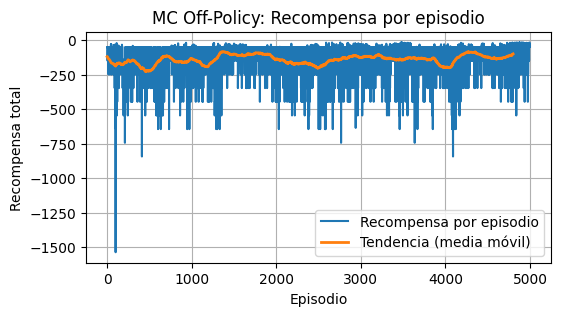

Máxima proporcion: -28


In [8]:
#@title Recompensa por episodio
plot_rewards(rewards_off)
print(f"Máxima proporcion: {rewards_off[-1]}")

In [13]:
# @title Tabla de valores Q
print("Valores Q para cada estado:\n", Q_off)

Valores Q para cada estado:
 [[  -7.88299282   -7.87558045   -7.81172579   -7.88680898]
 [  -7.30403023   -7.95809906   -7.25749153   -7.86746866]
 [  -7.25604257   -7.31032018   -7.27872063   -7.3226612 ]
 [  -7.96808822   -7.1948069    -7.28687269   -7.34655666]
 [  -6.65111079   -6.560258     -6.58051332   -6.58832623]
 [  -7.3137483    -7.24962184   -7.26537787   -6.67339135]
 [  -6.57482256   -6.66533615   -6.52046344   -6.69110044]
 [  -6.64379945   -5.93872589   -5.96736274   -5.98112573]
 [  -5.92862794   -5.23927085   -5.24466051   -5.24589895]
 [  -5.1303019    -4.50203362   -4.50256736   -5.13001801]
 [  -4.49402087   -3.69684905   -3.69692744   -5.22485836]
 [  -3.47911756   -3.67066085   -2.84990338   -4.40561046]
 [  -7.86838219   -7.32966133   -7.3285766    -7.90758347]
 [  -7.31679296   -7.2735945    -7.99288545   -7.90969545]
 [  -7.32705311   -7.23931807   -7.28622491   -7.32324922]
 [  -6.70146245   -7.28612745   -7.19880214   -7.97042661]
 [  -7.27236158   -7.254183

In [29]:
# @title Política final
pi_off_grid, actions_off, grid_off = pi_star_from_Q_offpolicy(Q_off)
print("Política óptima obtenida\n", pi_off_grid)
print("Acciones", actions_off)
print("Para el siguiente grid\n", grid_off)

Política óptima obtenida
 [[0 0 2 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 0 3]
 [0 0 2 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 2 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 3]
 [0 0 0 3]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 3]
 [0 0 0 0]
 [0 0 0 3]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Acciones 2, 2, 0, 1, 1, 3, 2, 1, 1, 1, 1, 2, 2, 1, 1, 0, 3, 3, 1, 1, 1, 1, 1, 2, 1, 0, 3, 0, 3, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
Para el siguiente grid
 o o o o o o o o o o o o
o o o o o o o o o o o o
o o o o o o o o o o o o
o C C C C C C C C C C x


## **4. Fin**